In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import matplotlib
import numpy as np
import pandas as pd

print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

numpy: 2.5.1
pandas: 3.0.3
matplotlib: 3.11.0


In [9]:
rng = np.random.default_rng(42)

corr = np.array([
    [1.0, 0.8, 0.5],
    [0.8, 1.0, 0.2],
    [0.5, 0.2, 1.0],
])
n_periods = 500
chol = np.linalg.cholesky(corr)

independent = rng.standard_normal((n_periods, 3))
correlated_returns = independent @ chol.T
series = np.cumsum(correlated_returns, axis=0)

print("target correlation matrix:")
print(corr)
print("realized correlation matrix:")
print(np.round(np.corrcoef(correlated_returns, rowvar=False), 2))

target correlation matrix:
[[1.  0.8 0.5]
 [0.8 1.  0.2]
 [0.5 0.2 1. ]]
realized correlation matrix:
[[1.   0.83 0.51]
 [0.83 1.   0.26]
 [0.51 0.26 1.  ]]


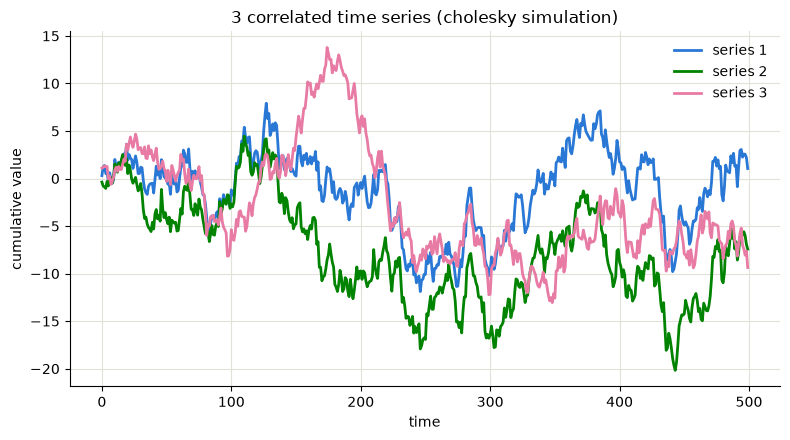

In [10]:
import matplotlib.pyplot as plt

colors = ["#2a78d6", "#008300", "#e87ba4"]
labels = ["series 1", "series 2", "series 3"]

fig, ax = plt.subplots(figsize=(8, 4.5))
for i in range(3):
    ax.plot(series[:, i], color=colors[i], linewidth=2, label=labels[i])

ax.set_xlabel("time")
ax.set_ylabel("cumulative value")
ax.set_title("3 correlated time series (cholesky simulation)")
ax.legend(frameon=False)
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()